# Lab 3 - CNN Architectures

**Course**: Deep Learning for Image Analysis

**Class**: M2 IASD App  

**Professor**: Mehyar MLAWEH

**Deadline:** 🗓️ **Saturday, March 14th (23:59)**

---

In this lab you will implement three landmark CNN architectures **from scratch** and evaluate them on a real medical image dataset.

| Architecture | Year | Key idea |
|---|---|---|
| AlexNet | 2012 | Deep CNNs at scale, ReLU, Dropout |
| GoogLeNet (Inception-v1) | 2014 | Inception modules, auxiliary classifiers |
| ResNet-18 & ResNet-34 | 2015 | Residual (skip) connections |

**Dataset:** [PneumoniaMNIST](https://medmnist.com/) from MedMNIST — chest X-ray binary classification (Normal vs Pneumonia), 28×28 images, ~6000 train / ~600 test samples. Runs on CPU in minutes.

⚠️ This notebook is **intentionally incomplete**.  
Whenever you see **`# TODO`**, you are expected to write code.


## 0 · Setup

In [ ]:
# Install dependencies
!pip install torch torchvision medmnist matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.0 MB/s eta 0:00:00


In [2]:
pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.2 MB/s eta 0:00:00


In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

import medmnist
from medmnist import PneumoniaMNIST

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128


## 1 · Dataset — PneumoniaMNIST

Chest X-rays resized to 28×28 px. Binary label: **0 = Normal**, **1 = Pneumonia**.

We up-sample to 224×224 so the architectures (designed for larger inputs) work without modification.

In [4]:
IMG_SIZE   = 224
BATCH_SIZE = 64
NUM_CLASSES = 2

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),   # architectures expect 3-channel input
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

train_dataset = PneumoniaMNIST(split='train', transform=train_transform, download=True)
val_dataset   = PneumoniaMNIST(split='val',   transform=val_transform,   download=True)
test_dataset  = PneumoniaMNIST(split='test',  transform=val_transform,   download=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) # TODO: Create DataLoader for train_dataset
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False) # TODO: Create DataLoader for val_dataset
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False) # TODO: Create DataLoader for test_dataset

print(f'Train samples : {len(train_dataset)}')
print(f'Val   samples : {len(val_dataset)}')
print(f'Test  samples : {len(test_dataset)}')

100%|██████████| 4.17M/4.17M [00:01<00:00, 3.42MB/s]


Train samples : 4708
Val   samples : 524
Test  samples : 624


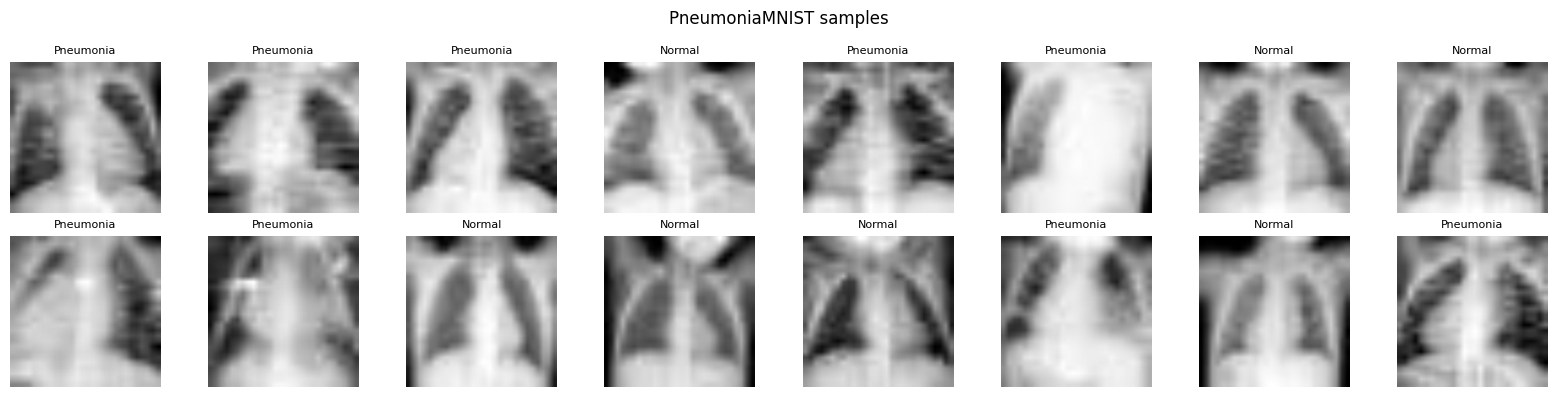

In [5]:
# Visualise a few training samples
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
class_names = ['Normal', 'Pneumonia']
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)   # un-normalise to view images
    ax.imshow(img[:, :, 0], cmap='gray')
    ax.set_title(class_names[labels[i].item()], fontsize=8)
    ax.axis('off')
plt.suptitle('PneumoniaMNIST samples', fontsize=12)
plt.tight_layout()
plt.show()

---
## 2 · AlexNet

**Reference:** Krizhevsky et al., 2012 — *ImageNet Classification with Deep Convolutional Neural Networks*

Architecture summary (adapted for 224×224 input):
```
Conv(96, 11×11, s=4) → MaxPool → Conv(256, 5×5) → MaxPool
→ Conv(384, 3×3) → Conv(384, 3×3) → Conv(256, 3×3) → MaxPool
→ FC(4096) → FC(4096) → FC(num_classes)
```

In [6]:
class AlexNet(nn.Module):
    """
    AlexNet adapted for arbitrary num_classes.
    Input: 3 × 224 × 224
    """

    def __init__(self, num_classes: int = 2, dropout: float = 0.5):
        super().__init__()

        # -------------------------------------------------------------- #
        # TODO   Build self.features                                  #
        # 5 convolutional blocks using nn.Sequential.                     #
        # Block pattern: Conv2d → ReLU → (optional MaxPool)              #
        #                                                                  #
        # Block 1: 3→96,  kernel=11, stride=4, pad=2 → MaxPool(3, s=2)  #
        # Block 2: 96→256, kernel=5,            pad=2 → MaxPool(3, s=2)  #
        # Block 3: 256→384, kernel=3,           pad=1                    #
        # Block 4: 384→384, kernel=3,           pad=1                    #
        # Block 5: 384→256, kernel=3,           pad=1 → MaxPool(3, s=2)  #
        # -------------------------------------------------------------- #
        self.features = nn.Sequential(
            # YOUR CODE HERE
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))

        # -------------------------------------------------------------- #
        # TODO   Build self.classifier                                #
        # 3-layer FC head using nn.Sequential.                            #
        # Add Dropout(p=dropout) before FC-1 and FC-2.                   #
        #                                                                  #
        # FC-1: 256×6×6 → 4096  + ReLU                                  #
        # FC-2:    4096 → 4096  + ReLU                                  #
        # FC-3:    4096 → num_classes                                    #
        # -------------------------------------------------------------- #
        self.classifier = nn.Sequential(
            # YOUR CODE HERE
            nn.Dropout(p=dropout),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),

            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),

            nn.Linear(4096, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # -------------------------------------------------------------- #
        # TODO  Forward pass                                         #
        # features → avgpool → flatten → classifier                      #
        # -------------------------------------------------------------- #
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


# Quick shape check
model = AlexNet(num_classes=NUM_CLASSES).to(device)
dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(device)
out   = model(dummy)
print(f'AlexNet output shape: {out.shape}')   # expected: torch.Size([2, 2])
print(f'AlexNet parameters : {sum(p.numel() for p in model.parameters()):,}')

AlexNet output shape: torch.Size([2, 2])
AlexNet parameters : 58,289,538


---
## 3 · GoogLeNet (Inception-v1)

**Reference:** Szegedy et al., 2014 — *Going Deeper with Convolutions*

Key idea: instead of choosing between 1×1, 3×3, 5×5 convolutions, apply **all in parallel** and let the network learn which scale matters.

```
InceptionModule:
  ┌─ 1×1 conv ──────────────────────────────────────────┐
  ├─ 1×1 bottleneck → 3×3 conv ────────────────────────┤
  ├─ 1×1 bottleneck → 5×5 conv ────────────────────────┤  → concat
  └─ 3×3 MaxPool   → 1×1 projection ──────────────────┘
```

In [9]:
class ConvBNReLU(nn.Module):
    """Reusable Conv → BatchNorm → ReLU block."""
    def __init__(self, in_ch, out_ch, kernel_size, stride=1, padding=0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride=stride,
                      padding=padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class InceptionModule(nn.Module):
    """
    Args:
        in_channels : input channels
        out_1x1     : branch-1 output channels
        red_3x3     : branch-2 reduction (1×1 before 3×3)
        out_3x3     : branch-2 output channels
        red_5x5     : branch-3 reduction (1×1 before 5×5)
        out_5x5     : branch-3 output channels
        out_pool    : branch-4 output channels (after MaxPool)
    """

    def __init__(self, in_channels, out_1x1, red_3x3, out_3x3,
                 red_5x5, out_5x5, out_pool):
        super().__init__()

        # -------------------------------------------------------------- #
        # TODO   Define the four branches                             #
        #                                                                  #
        # branch1 : single ConvBNReLU(1×1)                               #
        # branch2 : ConvBNReLU(1×1)  →  ConvBNReLU(3×3, padding=1)      #
        # branch3 : ConvBNReLU(1×1)  →  ConvBNReLU(5×5, padding=2)      #
        # branch4 : MaxPool2d(3×3, stride=1, padding=1)                  #
        #           → ConvBNReLU(1×1)                                     #
        # All branches must output the same spatial size (H, W).          #
        # -------------------------------------------------------------- #
        self.branch1 = ConvBNReLU(in_channels, out_1x1, kernel_size=1)  # YOUR CODE HERE
        self.branch2 = nn.Sequential(
            ConvBNReLU(in_channels, red_3x3, kernel_size=1),
            ConvBNReLU(red_3x3, out_3x3, kernel_size=3, padding=1)
        ) # YOUR CODE HERE
        self.branch3 = nn.Sequential(
            ConvBNReLU(in_channels, red_5x5, kernel_size=1),
            ConvBNReLU(red_5x5, out_5x5, kernel_size=5, padding=2)
        )  # YOUR CODE HERE
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            ConvBNReLU(in_channels, out_pool, kernel_size=1)
        )  # YOUR CODE HERE

    def forward(self, x):
        # -------------------------------------------------------------- #
        # TODO   Run x through all 4 branches, then concatenate      #
        # along the channel dimension (dim=1).                            #
        # -------------------------------------------------------------- #
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        return torch.cat([b1, b2, b3, b4], dim=1)


class AuxiliaryClassifier(nn.Module):
    """
    Auxiliary classifier — active only during training.
    Helps gradients reach early layers in a very deep network.

    TODO  — after implementing, explain in a markdown cell below:
    Why is this needed? What problem does it solve?
    Why is it removed at inference time?
    """
    def __init__(self, in_channels, num_classes, dropout=0.7):
        super().__init__()
        self.pool    = nn.AdaptiveAvgPool2d((4, 4))
        self.conv    = ConvBNReLU(in_channels, 128, kernel_size=1)
        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(128 * 4 * 4, 1024)
        self.relu    = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(p=dropout)
        self.fc2     = nn.Linear(1024, num_classes)

    def forward(self, x):
        # -------------------------------------------------------------- #
        # TODO   Forward through pool → conv → flatten → fc1         #
        # → relu → dropout → fc2                                          #
        # -------------------------------------------------------------- #
        x = self.pool(x)
        x = self.conv(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x


class GoogLeNet(nn.Module):
    """
    Full GoogLeNet — 9 Inception modules, Global Average Pooling head.
    Auxiliary classifiers are active during training only.
    """

    def __init__(self, num_classes=2, aux_logits=True, dropout=0.4):
        super().__init__()
        self.aux_logits = aux_logits

        # Stem
        self.conv1 = ConvBNReLU(3,   64, kernel_size=7, stride=2, padding=3)
        self.pool1 = nn.MaxPool2d(3, stride=2, padding=1)
        self.conv2 = ConvBNReLU(64,  64, kernel_size=1)
        self.conv3 = ConvBNReLU(64, 192, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(3, stride=2, padding=1)

        # Inception stages  (in_ch, 1×1, red3, 3×3, red5, 5×5, pool_proj)
        self.inception3a = InceptionModule(192,  64,  96, 128, 16,  32,  32)
        self.inception3b = InceptionModule(256, 128, 128, 192, 32,  96,  64)
        self.pool3       = nn.MaxPool2d(3, stride=2, padding=1)

        self.inception4a = InceptionModule(480, 192,  96, 208, 16,  48,  64)
        self.inception4b = InceptionModule(512, 160, 112, 224, 24,  64,  64)
        self.inception4c = InceptionModule(512, 128, 128, 256, 24,  64,  64)
        self.inception4d = InceptionModule(512, 112, 144, 288, 32,  64,  64)
        self.inception4e = InceptionModule(528, 256, 160, 320, 32, 128, 128)
        self.pool4       = nn.MaxPool2d(3, stride=2, padding=1)

        self.inception5a = InceptionModule(832, 256, 160, 320, 32, 128, 128)
        self.inception5b = InceptionModule(832, 384, 192, 384, 48, 128, 128)

        # Head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=dropout)
        self.fc      = nn.Linear(1024, num_classes)

        # Auxiliary classifiers
        if aux_logits:
            self.aux1 = AuxiliaryClassifier(512, num_classes)
            self.aux2 = AuxiliaryClassifier(528, num_classes)
        else:
            self.aux1 = self.aux2 = None

    def forward(self, x):
        """
        TODO   Full forward pass.

        Follow the stage order:
          stem → inception3a → inception3b → pool3
               → inception4a → [aux1 if training]
               → inception4b → inception4c → inception4d → [aux2 if training]
               → inception4e → pool4
               → inception5a → inception5b
               → avgpool → flatten → dropout → fc

        Return:
          (main, aux1, aux2)  during training with aux_logits=True
          main                otherwise
        """
        x = self.conv1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.pool2(x)

        x = self.inception3a(x)
        x = self.inception3b(x)
        x = self.pool3(x)

        x = self.inception4a(x)
        aux1 = None
        if self.aux_logits and self.training:
            aux1 = self.aux1(x)

        x = self.inception4b(x)
        x = self.inception4c(x)
        x = self.inception4d(x)

        aux2 = None
        if self.aux_logits and self.training:
            aux2 = self.aux2(x)

        x = self.inception4e(x)
        x = self.pool4(x)

        x = self.inception5a(x)
        x = self.inception5b(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)

        if self.training and self.aux_logits:
            return x, aux1, aux2
        return x


# Shape check
model = GoogLeNet(num_classes=NUM_CLASSES, aux_logits=True).to(device)
model.train()
dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(device)
out   = model(dummy)
print(f'GoogLeNet train output: main={out[0].shape}, aux1={out[1].shape}, aux2={out[2].shape}')
model.eval()
out = model(dummy)
print(f'GoogLeNet eval  output: {out.shape}')
print(f'GoogLeNet parameters : {sum(p.numel() for p in model.parameters()):,}')

GoogLeNet train output: main=torch.Size([2, 2]), aux1=torch.Size([2, 2]), aux2=torch.Size([2, 2])
GoogLeNet eval  output: torch.Size([2, 2])
GoogLeNet parameters : 10,316,966


**Question:** Why does GoogLeNet return a tuple during training but a single tensor during eval? Write your answer here.

> During training, GoogLeNet returns a tuple because it includes the outputs of the auxiliary classifiers (aux1 and aux2) in addition to the main output. These auxiliary outputs help improve training by providing additional gradient signals to earlier layers.
During evaluation, the auxiliary classifiers are not needed, so the model only returns the main output tensor used for the final prediction.

---
## 4 · ResNet — two variants

**Reference:** He et al., 2015 — *Deep Residual Learning for Image Recognition*

The key equation for a residual block:
$$\mathbf{y} = \mathcal{F}(\mathbf{x}) + \mathbf{x}$$

You will implement **ResNet-18** and **ResNet-34** — same architecture, different depth.

| | ResNet-18 | ResNet-34 |
|---|---|---|
| Stage 1 | 2 blocks | 3 blocks |
| Stage 2 | 2 blocks | 4 blocks |
| Stage 3 | 2 blocks | 6 blocks |
| Stage 4 | 2 blocks | 3 blocks |
| Total layers | 18 | 34 |

In [10]:
class BasicBlock(nn.Module):
    """
    Residual block for ResNet-18 / 34.

    Structure:
        x ──→ Conv(3×3) → BN → ReLU → Conv(3×3) → BN ──→ (+) → ReLU
        └──────────────── shortcut (identity or projection) ─────────┘
    """
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        # -------------------------------------------------------------- #
        # TODO   Define the two conv layers with BatchNorm            #
        #                                                                  #
        # conv1 : 3×3, stride=stride, padding=1, bias=False              #
        # bn1                                                              #
        # relu                                                             #
        # conv2 : 3×3, stride=1,      padding=1, bias=False              #
        # bn2                                                              #
        #                                                                  #
        # Note: the final ReLU is applied AFTER the shortcut addition.    #
        # -------------------------------------------------------------- #
        # YOUR CODE HERE
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        # -------------------------------------------------------------- #
        # TODO   Residual forward                                     #
        # out = conv1 → bn1 → relu → conv2 → bn2                        #
        # Apply downsample to identity if not None                        #
        # out = out + identity    ← the residual addition                #
        # Apply relu and return                                           #
        # -------------------------------------------------------------- #
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out = out + identity
        out = self.relu(out)
        return out


class ResNet(nn.Module):
    """
    Generic ResNet. Pass different `layers` lists to get ResNet-18 or 34.
    """

    def __init__(self, layers, num_classes=2):
        super().__init__()
        self.in_channels = 64

        # -------------------------------------------------------------- #
        # TODO   Stem                                                 #
        # conv1   : 3→64, kernel=7, stride=2, padding=3, bias=False      #
        # bn1     : BatchNorm2d(64)                                       #
        # relu    : ReLU(inplace=True)                                    #
        # maxpool : MaxPool2d(kernel=3, stride=2, padding=1)              #
        # -------------------------------------------------------------- #
        # YOUR CODE HERE
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # -------------------------------------------------------------- #
        # TODO   Four residual stages via _make_layer()               #
        # layer1 :  64 channels, layers[0] blocks, stride=1              #
        # layer2 : 128 channels, layers[1] blocks, stride=2              #
        # layer3 : 256 channels, layers[2] blocks, stride=2              #
        # layer4 : 512 channels, layers[3] blocks, stride=2              #
        # -------------------------------------------------------------- #
        # YOUR CODE HERE
        self.layer1 = self._make_layer(64, layers[0], stride=1)
        self.layer2 = self._make_layer(128, layers[1], stride=2)
        self.layer3 = self._make_layer(256, layers[2], stride=2)
        self.layer4 = self._make_layer(512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride=1):
        """
        TODO   Build one residual stage.

        A 1×1 projection shortcut is needed when:
          - stride > 1  (spatial size changes), or
          - self.in_channels != out_channels  (channel count changes)

        Steps:
          1. Build downsample = Sequential(Conv1×1 + BN) if needed, else None
          2. Append first BasicBlock(self.in_channels, out_channels, stride, downsample)
          3. Update self.in_channels = out_channels
          4. Append remaining (num_blocks-1) BasicBlocks with stride=1
          5. Return nn.Sequential(*blocks)
        """
        blocks = []
        downsample = None
        if stride > 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        blocks.append(BasicBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels

        for _ in range(1, num_blocks):
            blocks.append(BasicBlock(self.in_channels, out_channels, stride=1))

        return nn.Sequential(*blocks)

    def forward(self, x):
        # -------------------------------------------------------------- #
        # TODO   stem → layer1 → layer2 → layer3 → layer4            #
        #           → avgpool → flatten → fc                              #
        # -------------------------------------------------------------- #
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

def resnet18(num_classes=2):
    return ResNet([2, 2, 2, 2], num_classes=num_classes)

def resnet34(num_classes=2):
    return ResNet([3, 4, 6, 3], num_classes=num_classes)


# Shape checks
for name, model in [('ResNet-18', resnet18(NUM_CLASSES)), ('ResNet-34', resnet34(NUM_CLASSES))]:
    model = model.to(device)
    dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    out   = model(dummy)
    params = sum(p.numel() for p in model.parameters())
    print(f'{name}  output={out.shape}  params={params:,}')

ResNet-18  output=torch.Size([2, 2])  params=11,177,538
ResNet-34  output=torch.Size([2, 2])  params=21,285,698


**Question:** ResNet-34 is almost twice as deep as ResNet-18 — why does it not suffer from vanishing gradients? Write your answer here.

> ResNet-34 doesn't suffer from vanishing gradients because it uses residual (skip) connections. These connections allow the gradient to flow directly through the identity path during backpropagation. So, the gradient can reach earlier layers more easily which make training deeper networks more stable and effective.

---
## 5 · Training utilities

In [11]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        optimizer.zero_grad()
        outputs = model(images)

        # Handle GoogLeNet tuple output (main, aux1, aux2)
        if isinstance(outputs, tuple):
            main, aux1, aux2 = outputs
            loss = criterion(main, labels) \
                 + 0.3 * criterion(aux1, labels) \
                 + 0.3 * criterion(aux2, labels)
        else:
            main = outputs
            loss = criterion(main, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds       = main.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images  = images.to(device)
        labels  = labels.squeeze().long().to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


def train(model, model_name, epochs=10, lr=1e-3):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0

    print(f'\n{"="*50}')
    print(f'Training {model_name}')
    print(f'{"="*50}')

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc = evaluate(model, val_loader,   criterion, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), f'{model_name}_best.pth')

        print(f'Epoch {epoch:02d}/{epochs}  '
              f'train_loss={tr_loss:.4f}  train_acc={tr_acc:.3f}  '
              f'val_loss={vl_loss:.4f}  val_acc={vl_acc:.3f}  '
              f'({time.time()-t0:.1f}s)')

    print(f'Best val acc: {best_val_acc:.4f}')
    return history

print('Training utilities ready.')

Training utilities ready.


---
## 6 · Train all models

Train each architecture for **10 epochs**. On CPU this takes ~5 min per model. On GPU ~1 min.

In [12]:
EPOCHS = 10

history_alexnet  = train(AlexNet(NUM_CLASSES),              'AlexNet',   epochs=EPOCHS)
history_googlenet= train(GoogLeNet(NUM_CLASSES),            'GoogLeNet', epochs=EPOCHS)
history_resnet18 = train(resnet18(NUM_CLASSES),             'ResNet-18', epochs=EPOCHS)
history_resnet34 = train(resnet34(NUM_CLASSES),             'ResNet-34', epochs=EPOCHS)


Training AlexNet
Epoch 01/10  train_loss=0.5253  train_acc=0.749  val_loss=0.4521  val_acc=0.811  (18.2s)
Epoch 02/10  train_loss=0.2425  train_acc=0.911  val_loss=0.2586  val_acc=0.903  (17.6s)
Epoch 03/10  train_loss=0.2121  train_acc=0.921  val_loss=0.2069  val_acc=0.926  (17.1s)
Epoch 04/10  train_loss=0.1850  train_acc=0.927  val_loss=0.1804  val_acc=0.918  (16.9s)
Epoch 05/10  train_loss=0.1720  train_acc=0.929  val_loss=0.1674  val_acc=0.941  (17.2s)
Epoch 06/10  train_loss=0.1513  train_acc=0.938  val_loss=0.1488  val_acc=0.950  (17.4s)
Epoch 07/10  train_loss=0.1349  train_acc=0.948  val_loss=0.1325  val_acc=0.956  (17.5s)
Epoch 08/10  train_loss=0.1284  train_acc=0.949  val_loss=0.1387  val_acc=0.948  (16.6s)
Epoch 09/10  train_loss=0.1179  train_acc=0.955  val_loss=0.1237  val_acc=0.958  (17.6s)
Epoch 10/10  train_loss=0.1122  train_acc=0.955  val_loss=0.1642  val_acc=0.950  (16.7s)
Best val acc: 0.9580

Training GoogLeNet
Epoch 01/10  train_loss=0.3436  train_acc=0.911  va

---
## 7 · Results & comparison

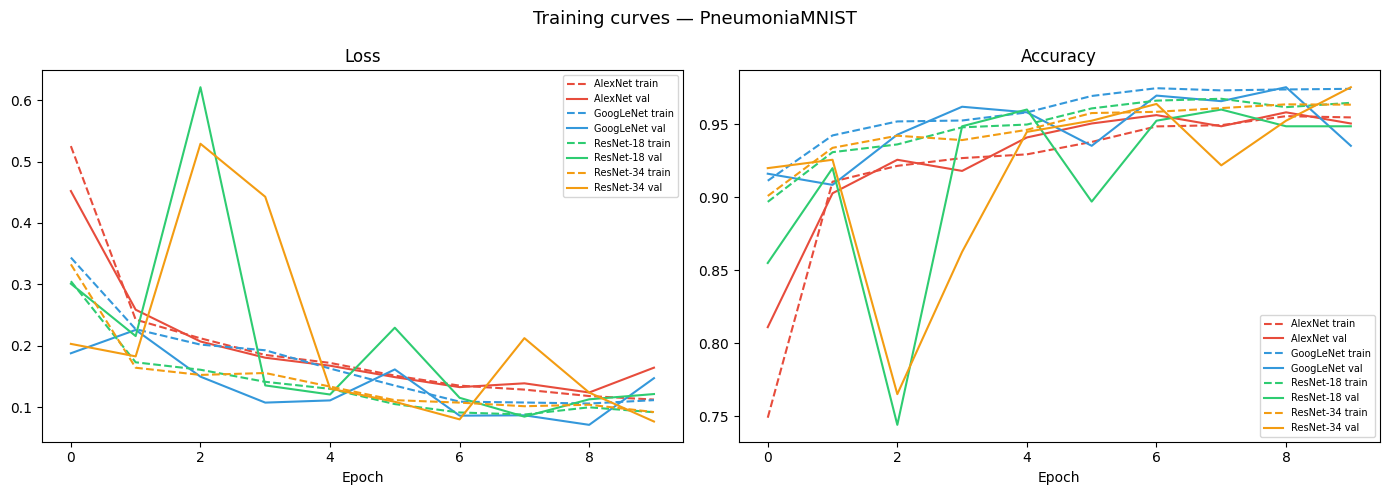

In [13]:
# --- Learning curves ---
all_histories = {
    'AlexNet':   history_alexnet,
    'GoogLeNet': history_googlenet,
    'ResNet-18': history_resnet18,
    'ResNet-34': history_resnet34,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for (name, h), c in zip(all_histories.items(), colors):
    axes[0].plot(h['train_loss'], label=f'{name} train', color=c, linestyle='--')
    axes[0].plot(h['val_loss'],   label=f'{name} val',   color=c)
    axes[1].plot(h['train_acc'],  label=f'{name} train', color=c, linestyle='--')
    axes[1].plot(h['val_acc'],    label=f'{name} val',   color=c)

axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=7)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=7)
plt.suptitle('Training curves — PneumoniaMNIST', fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
# --- Final test accuracy & param count ---
criterion = nn.CrossEntropyLoss()

models_eval = {
    'AlexNet':   AlexNet(NUM_CLASSES),
    'GoogLeNet': GoogLeNet(NUM_CLASSES, aux_logits=False),
    'ResNet-18': resnet18(NUM_CLASSES),
    'ResNet-34': resnet34(NUM_CLASSES),
}

results = {}
for name, m in models_eval.items():
    m.load_state_dict(torch.load(f'{name}_best.pth', map_location=device), strict =False)
    m = m.to(device)
    _, test_acc = evaluate(m, test_loader, criterion, device)

    # Measure inference latency (avg over 100 forward passes)
    m.eval()
    dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE).to(device)
    with torch.no_grad():
        for _ in range(10): m(dummy)   # warm-up
        t0 = time.time()
        for _ in range(100): m(dummy)
        lat_ms = (time.time() - t0) / 100 * 1000

    params_M = sum(p.numel() for p in m.parameters()) / 1e6
    results[name] = {'test_acc': test_acc, 'params_M': params_M, 'latency_ms': lat_ms}
    print(f'{name:12s}  test_acc={test_acc:.4f}  params={params_M:.1f}M  latency={lat_ms:.1f}ms')

AlexNet       test_acc=0.8638  params=58.3M  latency=1.9ms
GoogLeNet     test_acc=0.8237  params=6.0M  latency=10.0ms
ResNet-18     test_acc=0.7901  params=11.2M  latency=2.2ms
ResNet-34     test_acc=0.8317  params=21.3M  latency=3.9ms


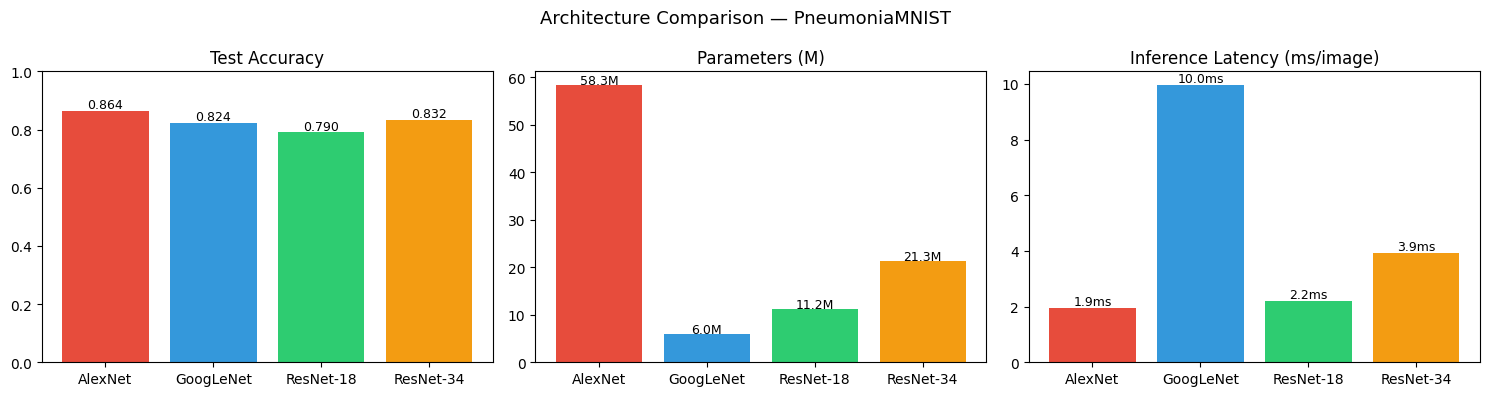

In [21]:
# --- Comparison bar charts ---
names     = list(results.keys())
test_accs = [results[n]['test_acc']   for n in names]
params    = [results[n]['params_M']   for n in names]
latencies = [results[n]['latency_ms'] for n in names]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
palette = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

axes[0].bar(names, test_accs, color=palette)
axes[0].set_title('Test Accuracy'); axes[0].set_ylim(0, 1)
for i, v in enumerate(test_accs): axes[0].text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar(names, params, color=palette)
axes[1].set_title('Parameters (M)')
for i, v in enumerate(params): axes[1].text(i, v+0.2, f'{v:.1f}M', ha='center', fontsize=9)

axes[2].bar(names, latencies, color=palette)
axes[2].set_title('Inference Latency (ms/image)')
for i, v in enumerate(latencies): axes[2].text(i, v+0.1, f'{v:.1f}ms', ha='center', fontsize=9)

plt.suptitle('Architecture Comparison — PneumoniaMNIST', fontsize=13)
plt.tight_layout()
plt.show()

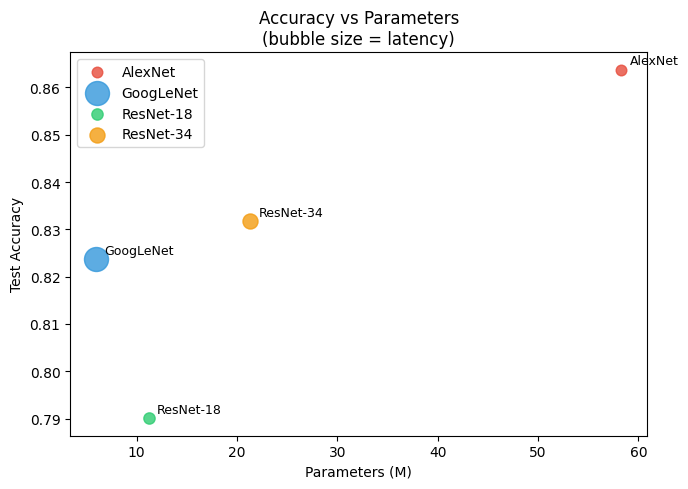

In [22]:
# --- Accuracy vs Parameters bubble chart ---
fig, ax = plt.subplots(figsize=(7, 5))
for name, c in zip(names, palette):
    r = results[name]
    ax.scatter(r['params_M'], r['test_acc'],
               s=r['latency_ms']*30, color=c, alpha=0.8, label=name)
    ax.annotate(name, (r['params_M'], r['test_acc']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.set_xlabel('Parameters (M)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Accuracy vs Parameters\n(bubble size = latency)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8 · Analysis questions

Answer each question in the cell below it.

**Q1.** Looking at the accuracy-vs-parameters chart, which architecture offers the best trade-off? Justify.

> GoogLeNet offer the best trade-off between accuracy and model size. It uses only about 6 million parameters, which is much fewer than the other architectures, while still achieving a good test accuracy. Compared to AlexNet and ResNet-34, it is much more parameter-efficient, making it a good balance between performance and efficiency.

**Q2.** GoogLeNet uses auxiliary classifiers during training. Remove them (`aux_logits=False`), retrain, and report the difference in final val accuracy.

In [23]:
# YOUR CODE HERE — train GoogLeNet without aux classifiers and compare
history_googlenet_noaux = train(
    GoogLeNet(NUM_CLASSES, aux_logits=False), 'GoogLeNet_noaux', epochs=EPOCHS
)

# Comparation
best_val_aux   = max(history_googlenet['val_acc'])
best_val_noaux = max(history_googlenet_noaux['val_acc'])
diff = best_val_noaux - best_val_aux

print(f'Best val acc with aux classifiers    : {best_val_aux:.4f}')
print(f'Best val acc without aux classifiers : {best_val_noaux:.4f}')
print(f'Difference (noaux - aux)             : {diff:.4f}')


Training GoogLeNet_noaux
Epoch 01/10  train_loss=0.2102  train_acc=0.910  val_loss=0.1588  val_acc=0.945  (28.5s)
Epoch 02/10  train_loss=0.1391  train_acc=0.947  val_loss=0.2670  val_acc=0.872  (27.9s)
Epoch 03/10  train_loss=0.1235  train_acc=0.951  val_loss=0.1756  val_acc=0.933  (27.1s)
Epoch 04/10  train_loss=0.1052  train_acc=0.955  val_loss=0.1427  val_acc=0.937  (27.1s)
Epoch 05/10  train_loss=0.0942  train_acc=0.964  val_loss=0.2160  val_acc=0.918  (26.9s)
Epoch 06/10  train_loss=0.0796  train_acc=0.970  val_loss=0.0754  val_acc=0.966  (27.0s)
Epoch 07/10  train_loss=0.0722  train_acc=0.971  val_loss=0.1104  val_acc=0.954  (27.0s)
Epoch 08/10  train_loss=0.0701  train_acc=0.971  val_loss=0.0785  val_acc=0.969  (27.3s)
Epoch 09/10  train_loss=0.0696  train_acc=0.972  val_loss=0.0926  val_acc=0.954  (27.9s)
Epoch 10/10  train_loss=0.0605  train_acc=0.976  val_loss=0.0702  val_acc=0.973  (27.0s)
Best val acc: 0.9733
Best val acc with aux classifiers    : 0.9752
Best val acc with

Answer : Removing the auxiliary classifiers caused a very small decrease in validation accuracy. The best validation accuracy went from 0.9752 with auxiliary classifiers to 0.9733 without them, which is a difference of -0.0019. This shows that the auxiliary classifiers slightly help training but the overall impact is small in this experiment.

**Q3** — Implement `ResNet-50` using a `BottleneckBlock` (1×1 → 3×3 → 1×1, expansion=4). Add it to the comparison.

In [31]:
class BottleneckBlock(nn.Module):
    """
    Bottleneck for ResNet-50/101/152.
    expansion = 4  →  output channels = planes * 4
    """
    expansion = 4

    def __init__(self, in_channels, planes, stride=1, downsample=None):
        super().__init__()
        # YOUR CODE HERE
        self.conv1 = nn.Conv2d(in_channels, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, planes * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        # YOUR CODE HERE
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv3(out)
        out = self.bn3(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out = out + identity
        out = self.relu(out)
        return out


def resnet50(num_classes=2):
    # YOUR CODE HERE — hint: use BottleneckBlock and layers=[3,4,6,3]
    return ResNet([3, 4, 6, 3], num_classes=num_classes)

In [32]:
# Shape check for ResNet-50
model = resnet50(NUM_CLASSES).to(device)

dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(device)
out = model(dummy)

print(f'ResNet-50 output shape: {out.shape}')
print(f'ResNet-50 parameters : {sum(p.numel() for p in model.parameters()):,}')

ResNet-50 output shape: torch.Size([2, 2])
ResNet-50 parameters : 21,285,698


The ResNet-50 implementation works correctly. The model produces the expected output shape (2, 2) and has about 21 million parameters, which is consistent with a deeper ResNet architecture.